# 탐색용 초기 노트북 (보고한 결과 아님)

이 노트북은 초기 탐색 단계의 실험(RandomForest, 3단계 위험등급, soft-voting 앙상블)입니다. 도로 지점을 `train_test_split`으로 **무작위 분할**했기 때문에 서로 가까운 지점이 학습과 평가에 함께 들어가는 **공간 누수**가 있고, 뒤쪽 셀의 클래스별 임계값도 같은 test set에서 골랐습니다. 그래서 여기 나온 점수는 부풀려진 값이며 **이 프로젝트가 보고한 결과가 아닙니다**. 보고한 결과는 README 4–5절의 공간 블록 교차검증 기준입니다.

**Early exploratory notebook; its scores are not the reported result.** It splits the road points at random (`train_test_split`), so neighbouring points end up in both train and test (spatial leakage), and the per-class thresholds in the later cells are chosen on the same test set. The scores below are therefore inflated. The reported results come from spatial block cross-validation; see README sections 4–5.

In [ ]:
import geopandas as gpd

gdf = gpd.read_file("data/road_points.gpkg")
gdf.head()

In [78]:
import fiona

# 레이어 목록 확인
fiona.listlayers("data/road_points.gpkg")

['road_points']

In [79]:
gdf.shape

(240098, 35)

In [ ]:
gdf.columns

In [ ]:
import pandas as pd

# 모든 열이 출력되도록 설정
pd.set_option('display.max_columns', None)

gdf.dtypes

In [ ]:
import pandas as pd

# 열 출력 제한 해제
pd.set_option('display.max_columns', None)  # 열 생략 없이 모두 출력
pd.set_option('display.expand_frame_repr', False)  # 넓어도 한 줄에 계속 출력

# 타입 정보 확인
col_types = gdf.dtypes.reset_index()
col_types.columns = ['column', 'dtype']
print(col_types)

In [83]:
# dist로 끝나는 컬럼 목록 추출
dist_cols = [col for col in gdf.columns if col.endswith('dist')]
print(dist_cols)

['preschool_dist', 'kind_dist', 'elem_dist', 'academy_dist', 'crossroads_dist', 'crosswalks_dist', 'tl_dist', 'busstop_dist']


In [84]:
# 각 dist 컬럼을 float으로 변환 (문자 -> 숫자 변환)
for col in dist_cols:
    gdf[col] = pd.to_numeric(gdf[col], errors='coerce')  # 변환 불가능한 값은 NaN 처리

In [85]:
print(gdf[dist_cols].dtypes)

preschool_dist     float64
kind_dist          float64
elem_dist          float64
academy_dist       float64
crossroads_dist    float64
crosswalks_dist    float64
tl_dist            float64
busstop_dist       float64
dtype: object


In [ ]:
gdf.dtypes

In [87]:
gdf1 = gdf.drop(columns=['geometry'])

In [ ]:
gdf1.isnull().sum()

In [89]:
gdf1 = gdf1.dropna(subset=['slope_30M1'])

In [90]:
gdf1_y_a = gdf1['is_accident']
gdf1_y_a_c = gdf1['accident_cnt']

In [91]:
gdf1 = gdf1.drop(columns=['is_accident','accident_cnt'])

In [92]:
from sklearn.preprocessing import LabelEncoder

# 복사
gdf_encoded = gdf1.copy()

# 라벨 인코더 객체 생성
le_dvyn = LabelEncoder()
le_onsd = LabelEncoder()

# 인코딩 적용
gdf_encoded['DVYN'] = le_dvyn.fit_transform(gdf_encoded['DVYN'])
gdf_encoded['ONSD'] = le_onsd.fit_transform(gdf_encoded['ONSD'])

from sklearn.preprocessing import MinMaxScaler

# 1. 정규화할 피처 리스트
scale_cols = ['weekday_h_pop','weekday_v_pop' , 'weekend_h_pop' ,'weekend_v_pop']

# 2. scaler 생성 및 학습
scaler = MinMaxScaler()
gdf_encoded[scale_cols] = scaler.fit_transform(gdf_encoded[scale_cols])

In [93]:
from sklearn.preprocessing import MinMaxScaler

# 1. 정규화할 피처 리스트
scale_cols = ['weekday_h_pop','weekday_v_pop' , 'weekend_h_pop' ,'weekend_v_pop']

# 2. scaler 생성 및 학습
scaler = MinMaxScaler()
gdf_encoded[scale_cols] = scaler.fit_transform(gdf_encoded[scale_cols])

In [ ]:
gdf_encoded.isnull().sum()

In [95]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier

In [96]:
X_train, X_test, y_train, y_test = train_test_split(gdf_encoded, gdf1_y_a, test_size = 0.2 , stratify=gdf1_y_a, random_state=2024, )

In [97]:
model = RandomForestClassifier(n_estimators=100, random_state=2024)
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [98]:
X_train.shape

(192051, 32)

In [ ]:
# 학습 완료된 모델이 clf라고 가정
importances = model.feature_importances_
# 피처 이름이 들어있는 리스트 (X의 column 순서와 같아야 함)
feature_names = gdf_encoded.columns if isinstance(gdf_encoded, pd.DataFrame) else gdf_encoded.drop(columns=['is_accident']).columns

# 딕셔너리 형태로 정리
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance.head(10))  # 상위 10개만 보기

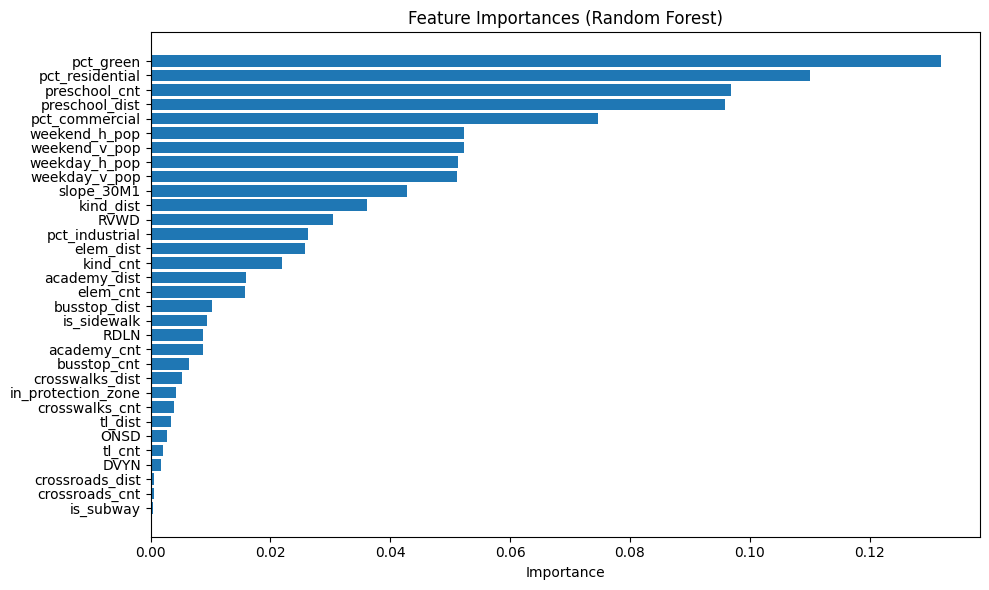

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

In [102]:
from sklearn.metrics import classification_report
print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     35643
           1       0.94      0.94      0.94     12370

    accuracy                           0.97     48013
   macro avg       0.96      0.96      0.96     48013
weighted avg       0.97      0.97      0.97     48013



In [ ]:
gdf1

In [104]:
def classify_risk(count):
    if count >= 3:
        return 'High'       # 고위험
    elif 2>= count >= 1:
        return 'Medium'     # 위험
    else:
        return 'Safe'       # 안전

gdf['risk_level'] = gdf['accident_cnt'].apply(classify_risk)

In [105]:
from sklearn.preprocessing import LabelEncoder

# 복사
gdf_encoded = gdf.copy()

# 라벨 인코더 객체 생성
le_dvyn = LabelEncoder()
le_onsd = LabelEncoder()

# 인코딩 적용
gdf_encoded['DVYN'] = le_dvyn.fit_transform(gdf_encoded['DVYN'])
gdf_encoded['ONSD'] = le_onsd.fit_transform(gdf_encoded['ONSD'])

from sklearn.preprocessing import MinMaxScaler

# 1. 정규화할 피처 리스트
scale_cols = ['weekday_h_pop','weekday_v_pop' , 'weekend_h_pop' ,'weekend_v_pop']

# 2. scaler 생성 및 학습
scaler = MinMaxScaler()
gdf_encoded[scale_cols] = scaler.fit_transform(gdf_encoded[scale_cols])

In [106]:
X = gdf_encoded.drop(columns=['risk_level', 'accident_cnt', 'is_accident','geometry'])  # target과 직접 연관된 변수 제거
y = gdf_encoded['risk_level']

In [107]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.90      0.86      0.88      4051
      Medium       0.89      0.89      0.89     11411
        Safe       0.98      0.98      0.98     44563

    accuracy                           0.96     60025
   macro avg       0.92      0.91      0.92     60025
weighted avg       0.96      0.96      0.96     60025

[[ 3496   491    64]
 [  334 10151   926]
 [   34   785 43744]]


In [108]:
probs = clf.predict_proba(X_test)
y_pred_new = []

for p in probs:
    if p[0] > 0.7:  # High
        y_pred_new.append('High')
    elif p[1] > 0.5:  # Medium
        y_pred_new.append('Medium')
    else:
        y_pred_new.append('Safe')

In [109]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

        High       0.98      0.51      0.67      4051
      Medium       0.91      0.86      0.89     11411
        Safe       0.93      0.99      0.96     44563

    accuracy                           0.93     60025
   macro avg       0.94      0.79      0.84     60025
weighted avg       0.93      0.93      0.92     60025



In [111]:
classes = clf.classes_  # 예: ['High', 'Medium', 'Safe']
probs = clf.predict_proba(X_test)  # shape: (n_samples, n_classes)

In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

# 결과 저장용
best_thresholds = {}
best_f1_scores = {}

for idx, cls in enumerate(classes):
    y_true_binary = (y_test == cls).astype(int)  # 해당 클래스 vs 나머지
    y_probs = probs[:, idx]

    precisions, recalls, thresholds = precision_recall_curve(y_true_binary, y_probs)

    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    
    best_thresholds[cls] = thresholds[best_idx]
    best_f1_scores[cls] = f1_scores[best_idx]

    print(f"Class: {cls}")
    print(f"→ Best threshold: {thresholds[best_idx]:.3f}, F1-score: {f1_scores[best_idx]:.3f}")

Class: High
→ Best threshold: 0.400, F1-score: 0.884
Class: Medium
→ Best threshold: 0.440, F1-score: 0.892
Class: Safe
→ Best threshold: 0.450, F1-score: 0.979


In [113]:
custom_preds = []

for p in probs:
    matched_class = None

    # 각 클래스에 대해 threshold를 넘는지 확인
    for i, cls in enumerate(classes):
        if p[i] >= best_thresholds[cls]:
            if matched_class is None or p[i] > p[classes.tolist().index(matched_class)]:
                matched_class = cls
    
    # threshold 넘는 게 없다면 확률 가장 높은 클래스로
    if matched_class is None:
        matched_class = classes[np.argmax(p)]
    
    custom_preds.append(matched_class)

In [114]:
from sklearn.metrics import classification_report

print(classification_report(y_test, custom_preds))

              precision    recall  f1-score   support

        High       0.90      0.87      0.88      4051
      Medium       0.89      0.89      0.89     11411
        Safe       0.98      0.98      0.98     44563

    accuracy                           0.96     60025
   macro avg       0.92      0.91      0.92     60025
weighted avg       0.96      0.96      0.96     60025



In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score, classification_report
import numpy as np

# 예측 확률 가져오기
classes = clf.classes_  # 예: ['High', 'Medium', 'Safe']
probs = clf.predict_proba(X_test)  # shape: (n_samples, n_classes)

# 1. 클래스별 최적 threshold 탐색
best_thresholds = {}
best_f1_scores = {}

for idx, cls in enumerate(classes):
    y_true_binary = (y_test == cls).astype(int)
    y_probs = probs[:, idx]

    precisions, recalls, thresholds = precision_recall_curve(y_true_binary, y_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

    best_idx = np.argmax(f1_scores)
    best_thresholds[cls] = thresholds[best_idx]
    best_f1_scores[cls] = f1_scores[best_idx]

    print(f"Class: {cls}")
    print(f"→ Best threshold: {thresholds[best_idx]:.3f}, F1-score: {f1_scores[best_idx]:.3f}")

# 2. threshold 기반 custom prediction 생성
custom_preds = []

for p in probs:
    matched_class = None
    max_prob = 0

    # 각 클래스에 대해 threshold 넘는 것 중 확률 가장 높은 클래스 선택
    for i, cls in enumerate(classes):
        if p[i] >= best_thresholds[cls]:
            if matched_class is None or p[i] > max_prob:
                matched_class = cls
                max_prob = p[i]

    # threshold 넘는 게 없으면 확률 가장 높은 클래스로 선택
    if matched_class is None:
        matched_class = classes[np.argmax(p)]

    custom_preds.append(matched_class)

# 3. 성능 평가
print("\n✅ Threshold-based Prediction 결과:")
print(classification_report(y_test, custom_preds))

In [125]:
import xgboost
print(xgboost.__version__)

3.0.2


In [129]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve, classification_report
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier



# 1. Cost-sensitive 개별 모델 정의
rf = RandomForestClassifier(
    class_weight='balanced',  # ✅ 문자열 그대로 사용
    random_state=42
)
xgb = XGBClassifier(scale_pos_weight=3, use_label_encoder=False, eval_metric='mlogloss', random_state=42)
gb = HistGradientBoostingClassifier(random_state=42)

# 2. 앙상블 모델 정의 (확률 평균)
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgb), ('gb', gb)],
    voting='soft'  # 확률 기반 평균
)

# 3. 모델 학습
ensemble.fit(X_train, y_train)

# 4. 예측 확률
probs = ensemble.predict_proba(X_test)
classes = ensemble.classes_

# 5. Threshold 최적화
best_thresholds = {}
best_f1_scores = {}

for idx, cls in enumerate(classes):
    y_true_binary = (y_test == cls).astype(int)
    y_probs = probs[:, idx]

    precisions, recalls, thresholds = precision_recall_curve(y_true_binary, y_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

    best_idx = np.argmax(f1_scores)
    best_thresholds[cls] = thresholds[best_idx]
    best_f1_scores[cls] = f1_scores[best_idx]

    print(f"Class: {cls}")
    print(f"→ Best threshold: {thresholds[best_idx]:.3f}, F1-score: {f1_scores[best_idx]:.3f}")

# 6. Threshold 기반 예측
custom_preds = []

for p in probs:
    matched_class = None
    max_prob = 0

    for i, cls in enumerate(classes):
        if p[i] >= best_thresholds[cls]:
            if matched_class is None or p[i] > max_prob:
                matched_class = cls
                max_prob = p[i]

    if matched_class is None:
        matched_class = classes[np.argmax(p)]

    custom_preds.append(matched_class)

# 7. 평가
print("\n✅ Threshold + Cost + Ensemble 기반 예측 결과:")
print(classification_report(y_test, custom_preds))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:39:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Class: High
→ Best threshold: 0.369, F1-score: 0.829
Class: Medium
→ Best threshold: 0.435, F1-score: 0.843
Class: Safe
→ Best threshold: 0.472, F1-score: 0.967

✅ Threshold + Cost + Ensemble 기반 예측 결과:
              precision    recall  f1-score   support

        High       0.88      0.79      0.83      4051
      Medium       0.83      0.84      0.84     11411
        Safe       0.96      0.97      0.97     44563

    accuracy                           0.93     60025
   macro avg       0.89      0.87      0.88     60025
weighted avg       0.93      0.93      0.93     60025

